In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert


def read_text_dataset(file, key):
    value = file[key][:]
    return bytes(value).decode()


def read_scalar(file, key, dtype=np.float32):
    return dtype(file[key][()].item())


def read_vector(file, key, dtype=np.float32):
    return np.asarray(file[key][:], dtype=dtype).reshape(-1)


def load_simulated_rf(path):
    with h5py.File(path, "r") as file:
        params = {
            "name": read_text_dataset(file, "name") if "name" in file else path.stem,
            "source": read_text_dataset(file, "source") if "source" in file else "simulated",
            "pitch": read_scalar(file, "pitch"),
            "c0": read_scalar(file, "c0"),
            "fs": read_scalar(file, "fs"),
            "fc": read_scalar(file, "fc"),
            "na": int(file["na"][()].item()),
            "nc": int(file["nc"][()].item()),
            "ns": int(file["ns"][()].item()),
            "zlims": read_vector(file, "zlims"),
            "angles_range": read_vector(file, "angles_range"),
            "t0": read_vector(file, "t0"),
        }

        rf = np.asarray(file["rf"][:], dtype=np.float32)

    na, nc, ns = params["na"], params["nc"], params["ns"]

    if rf.shape == (na, nc, ns):
        data = rf
    elif rf.shape == (ns, nc, na):
        data = np.transpose(rf, (2, 1, 0))
    elif rf.shape == (ns, nc) and na == 1:
        data = rf.T[None, :, :]
    else:
        raise ValueError(
            f"Unexpected RF shape. Expected {(na, nc, ns)} or {(ns, nc, na)}, got {rf.shape}."
        )

    if not np.isfinite(data).all():
        raise ValueError("RF contains NaN or Inf values.")

    if np.max(np.abs(data)) == 0:
        raise ValueError("RF is all zeros.")

    if params["t0"].size == 1:
        params["t0"] = np.full(na, params["t0"][0], dtype=np.float32)

    params["data"] = data.astype(np.float32)

    return params


def get_angles(params):
    na = params["na"]
    angles_range = params["angles_range"].astype(np.float32)

    if na == 1:
        return np.array([np.mean(angles_range)], dtype=np.float32)

    return np.linspace(angles_range[0], angles_range[1], na, dtype=np.float32)


def das_plane_wave(params, nx=301, nz=512, xlims=(-15e-3, 15e-3)):
    rf = params["data"]
    na = params["na"]
    nc = params["nc"]
    ns = params["ns"]
    pitch = params["pitch"]
    c0 = params["c0"]
    fs = params["fs"]
    t0 = params["t0"]
    zlims = params["zlims"]

    angles = get_angles(params)

    element_x = ((np.arange(nc, dtype=np.float32) - (nc - 1) / 2) * pitch).astype(np.float32)

    x_axis = np.linspace(xlims[0], xlims[1], nx, dtype=np.float32)
    z_axis = np.linspace(zlims[0], zlims[1], nz, dtype=np.float32)

    x_grid, z_grid = np.meshgrid(x_axis, z_axis)

    beamformed = np.zeros((nz, nx), dtype=np.float32)

    for ia, theta in enumerate(angles):
        #raw_tx_delays = element_x * np.sin(theta) / c0
        #tx_delay_offset = np.min(raw_tx_delays)

        #tx_time = (x_grid * np.sin(theta) + z_grid * np.cos(theta)) / c0 - tx_delay_offset

        tx_time = (x_grid * np.sin(theta) + z_grid * np.cos(theta)) / c0
        time_axis = t0[ia] + np.arange(ns, dtype=np.float32) / fs

        image_angle = np.zeros((nz, nx), dtype=np.float32)

        for ic in range(nc):
            rx_time = np.sqrt((x_grid - element_x[ic]) ** 2 + z_grid ** 2) / c0
            total_time = tx_time + rx_time

            channel_rf = rf[ia, ic, :]

            delayed = np.interp(
                total_time.ravel(),
                time_axis,
                channel_rf,
                left=0.0,
                right=0.0,
            ).reshape(nz, nx)

            image_angle += delayed.astype(np.float32)

        beamformed += image_angle

    beamformed /= np.float32(na * nc)

    return beamformed, x_axis, z_axis


def make_bmode(beamformed, dynamic_range_db=60):
    analytic = hilbert(beamformed, axis=0)
    envelope = np.abs(analytic)

    max_value = np.max(envelope)

    if max_value <= 0 or not np.isfinite(max_value):
        raise ValueError("Invalid envelope normalization value.")

    envelope = envelope / max_value
    bmode = 20 * np.log10(envelope + np.finfo(np.float32).eps)
    bmode = np.clip(bmode, -dynamic_range_db, 0)

    return bmode


def show_bmode(bmode, x_axis, z_axis, params, dynamic_range_db=60):
    extent = [
        x_axis[0],
        x_axis[-1],
        z_axis[-1],
        z_axis[0],
    ]

    plt.figure(figsize=(7, 7))
    plt.imshow(
        bmode,
        cmap="gray",
        extent=extent,
        vmin=-dynamic_range_db,
        vmax=0,
        aspect="auto",
    )
    plt.xlabel("x [m]")
    plt.ylabel("z [m]")
    plt.title(f"{params['name']} | DAS B-mode")
    plt.colorbar(label="dB")
    plt.tight_layout()
    plt.show()

File: /home/panda/rf_data/dataset/simulated/l115v_cyst_pw_rf.hdf5
Name: L11-5v_cyst_plane_wave_12MHz
RF shape [na, nc, ns]: (1, 128, 6052)
RF dtype: float32
RF abs max: 5.0305482e-24
zlims: [0.008 0.042] (2,)
angles_range: [0. 0.] (2,)
t0: [1.04e-05] (1,)


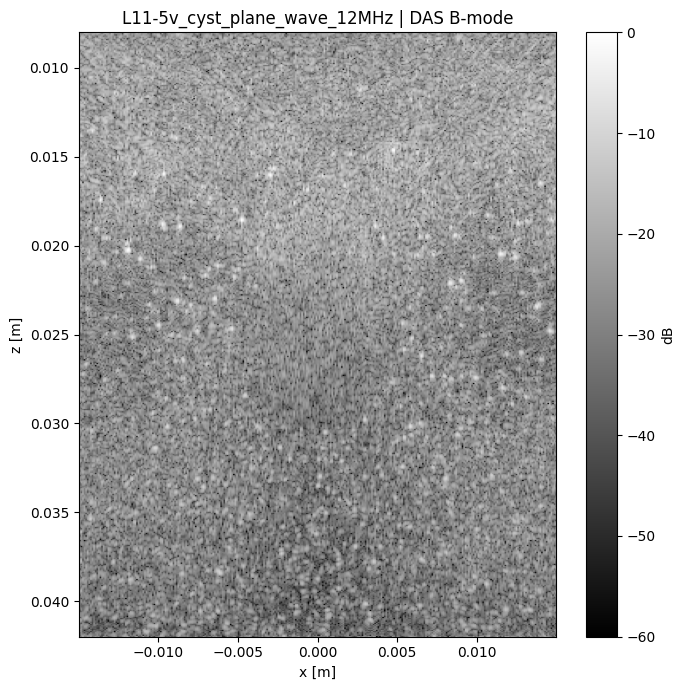

In [2]:
input_file = Path("/home/panda/rf_data/dataset/simulated/l115v_cyst_pw_rf.hdf5")

if not input_file.exists():
    candidates = sorted(Path(".").glob("*.hdf5")) + sorted(Path(".").glob("*.h5"))
    if not candidates:
        raise FileNotFoundError("No .hdf5 or .h5 file found in the current folder.")
    input_file = candidates[0]

params = load_simulated_rf(input_file)

print("File:", input_file)
print("Name:", params["name"])
print("RF shape [na, nc, ns]:", params["data"].shape)
print("RF dtype:", params["data"].dtype)
print("RF abs max:", np.max(np.abs(params["data"])))
print("zlims:", params["zlims"], params["zlims"].shape)
print("angles_range:", params["angles_range"], params["angles_range"].shape)
print("t0:", params["t0"], params["t0"].shape)

beamformed, x_axis, z_axis = das_plane_wave(
    params,
    nx=301,
    nz=512,
    xlims=(-15e-3, 15e-3),
)

bmode = make_bmode(beamformed, dynamic_range_db=60)

show_bmode(
    bmode,
    x_axis,
    z_axis,
    params,
    dynamic_range_db=60,
)